### Import Libraries

In [31]:
import os
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from scipy.io import loadmat
from skimage.draw import disk
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks

### Define Dataset Path

In [32]:
train_img_dir = "Dataset/ShanghaiTech/part_A/train_data/images"
train_gt_dir = "Dataset/ShanghaiTech/part_A/train_data/ground-truth"
test_img_dir = "Dataset/ShanghaiTech/part_A/test_data/images"
test_gt_dir = "Dataset/ShanghaiTech/part_A/test_data/ground-truth"

density_map_dir = "Dataset/ShanghaiTech/density_maps"
os.makedirs(density_map_dir, exist_ok=True)


## Density map generator

In [33]:
def generate_density_map(image, points, sigma=4):
    h, w = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for point in points:
        x = min(int(point[0]), w - 1)
        y = min(int(point[1]), h - 1)
        rr, cc = disk((y, x), sigma, shape=density.shape)
        density[rr, cc] += 1
    return density


## Generate and Save Density Maps (with normalization)

In [34]:
train_imgs = sorted(glob(os.path.join(train_img_dir, "*.jpg")))

for img_path in tqdm(train_imgs):
    fname = os.path.basename(img_path).replace(".jpg", "")
    gt_path = os.path.join(train_gt_dir, f"GT_{fname}.mat")
    mat = loadmat(gt_path)
    points = mat["image_info"][0][0][0][0][0]

    image = cv2.imread(img_path)
    density = generate_density_map(image, points)

    np.save(os.path.join(density_map_dir, f"{fname}.npy"), density)


100%|████████████████████████████████████████████████████████████████████████████████| 300/300 [00:07<00:00, 38.78it/s]


## Data Generator

In [35]:
class CrowdDataset(tf.keras.utils.Sequence):
    def __init__(self, image_paths, density_paths, batch_size=4, input_size=(224, 224)):
        self.image_paths = image_paths
        self.density_paths = density_paths
        self.batch_size = batch_size
        self.input_size = input_size

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        X = []
        Y = []
        for i in range(self.batch_size):
            index = idx * self.batch_size + i
            image = cv2.imread(self.image_paths[index])
            image = cv2.resize(image, self.input_size)
            image = image.astype(np.float32) / 255.0

            fname = os.path.basename(self.image_paths[index]).replace(".jpg", "")
            density = np.load(self.density_paths[index])
            density = cv2.resize(density, self.input_size)
            density = density.astype(np.float32)
            density *= (np.sum(density) / (np.sum(density) + 1e-6))  # Preserve total count

            X.append(image)
            Y.append(density[..., np.newaxis])
        return np.array(X), np.array(Y)


## Define U-NET model

In [36]:
def unet(input_shape=(224, 224, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(256, 3, activation='relu', padding='same')(u5)

    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, 3, activation='relu', padding='same')(u6)

    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, 3, activation='relu', padding='same')(u7)

    outputs = layers.Conv2D(1, 1, activation='linear')(c7)

    return models.Model(inputs, outputs)


### Prepare Training Dataset

In [37]:
train_images = sorted(glob(os.path.join(train_img_dir, "*.jpg")))
train_density = sorted(glob(os.path.join(density_map_dir, "*.npy")))

train_gen = CrowdDataset(train_images, train_density, batch_size=4)


### Compile model

In [38]:
model = unet()
model.compile(optimizer='adam', loss='mse')
model.summary()



Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_42 (Conv2D)            │ (None, 224, 224, 64)      │           1,792 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_43 (Conv2D)            │ (None, 224, 224, 64)      │          36,928 │ conv2d_42[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_9               │ (None, 112, 112, 64)      │               0 │ conv2d_43[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_44 (Conv2D)            │ (None, 112, 112, 128)     │          73,856 │ max_pooling2d_9[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_45 (Conv2D)            │ (None, 112, 112, 128)     │         147,584 │ conv2d_44[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_10              │ (None, 56, 56, 128)       │               0 │ conv2d_45[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_46 (Conv2D)            │ (None, 56, 56, 256)       │         295,168 │ max_pooling2d_10[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_47 (Conv2D)            │ (None, 56, 56, 256)       │         590,080 │ conv2d_46[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_11              │ (None, 28, 28, 256)       │               0 │ conv2d_47[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_48 (Conv2D)            │ (None, 28, 28, 512)       │       1,180,160 │ max_pooling2d_11[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_49 (Conv2D)            │ (None, 28, 28, 512)       │       2,359,808 │ conv2d_48[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d_3               │ (None, 56, 56, 512)       │               0 │ conv2d_49[0][0]            │
│ (UpSampling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_9 (Concatenate)   │ (None, 56, 56, 768)       │               0 │ up_sampling2d_3[0][0],     │
│                               │                           │                 │ conv2d_47[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_50 (Conv2D)            │ (None, 56, 56, 256)       │       1,769,72

 Total params: 7,008,321 (26.73 MB)

 Trainable params: 7,008,321 (26.73 MB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [39]:
model.fit(train_gen, epochs=30)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 37s 466ms/step - loss: 0.1548
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 458ms/step - loss: 0.0510
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 457ms/step - loss: 0.0480
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 458ms/step - loss: 0.0520
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 461ms/step - loss: 0.0500
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 459ms/step - loss: 0.0504
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 456ms/step - loss: 0.0460
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 464ms/step - loss: 0.0504
Epoch 9/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 463ms/step - loss: 0.0480
Epoch 10/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 478ms/step - loss: 0.0484
Epoch 11/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 36s 474ms/step - loss: 0.0493
Epoch 12/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 466ms/step - loss: 0.0490
Epoch 13/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 461ms/step - loss: 0.0498
Epoch 14/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 459ms/step - loss: 0.0513
Epoch 15/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 

### Evaluation

In [40]:
test_images = sorted(glob(os.path.join(test_img_dir, "*.jpg")))
test_gt = sorted(glob(os.path.join(test_gt_dir, "*.mat")))

mae = 0
mse = 0
for i in tqdm(range(len(test_images))):
    image = cv2.imread(test_images[i])
    image_resized = cv2.resize(image, (224, 224)).astype(np.float32) / 255.0

    gt = loadmat(test_gt[i])
    points = gt["image_info"][0][0][0][0][0]
    gt_count = len(points)

    pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
    pred_count = np.sum(pred_density)

    mae += abs(gt_count - pred_count)
    mse += (gt_count - pred_count) ** 2

mae /= len(test_images)
mse = np.sqrt(mse / len(test_images))
print(f"MAE: {mae:.2f}, RMSE: {mse:.2f}")


  0%|                                                                                          | 0/182 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


  1%|▍                                                                                 | 1/182 [00:00<00:42,  4.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


  1%|▉                                                                                 | 2/182 [00:00<00:27,  6.46it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


 99%|███████████████████████████████████████████████████████████████████████████████ | 180/182 [00:15<00:00, 11.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


100%|████████████████████████████████████████████████████████████████████████████████| 182/182 [00:16<00:00, 11.34it/s]

MAE: 1374.90, RMSE: 1532.37


### Visualization

In [41]:
def visualize_result(image_path, mat_path, model, input_size=(224, 224)):
    # Load image
    image = cv2.imread(image_path)
    image_resized = cv2.resize(image, input_size).astype(np.float32) / 255.0

    # Ground truth count
    mat = loadmat(mat_path)
    points = mat["image_info"][0][0][0][0][0]
    gt_density = generate_density_map(image, points)
    gt_resized = cv2.resize(gt_density, input_size)

    # Predicted density
    pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
    pred_count = np.sum(pred_density)
    gt_count = len(points)

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gt_resized, cmap='jet')
    plt.title(f"Ground Truth (Count: {gt_count})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_density, cmap='jet')
    plt.title(f"Predicted (Count: {pred_count:.2f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


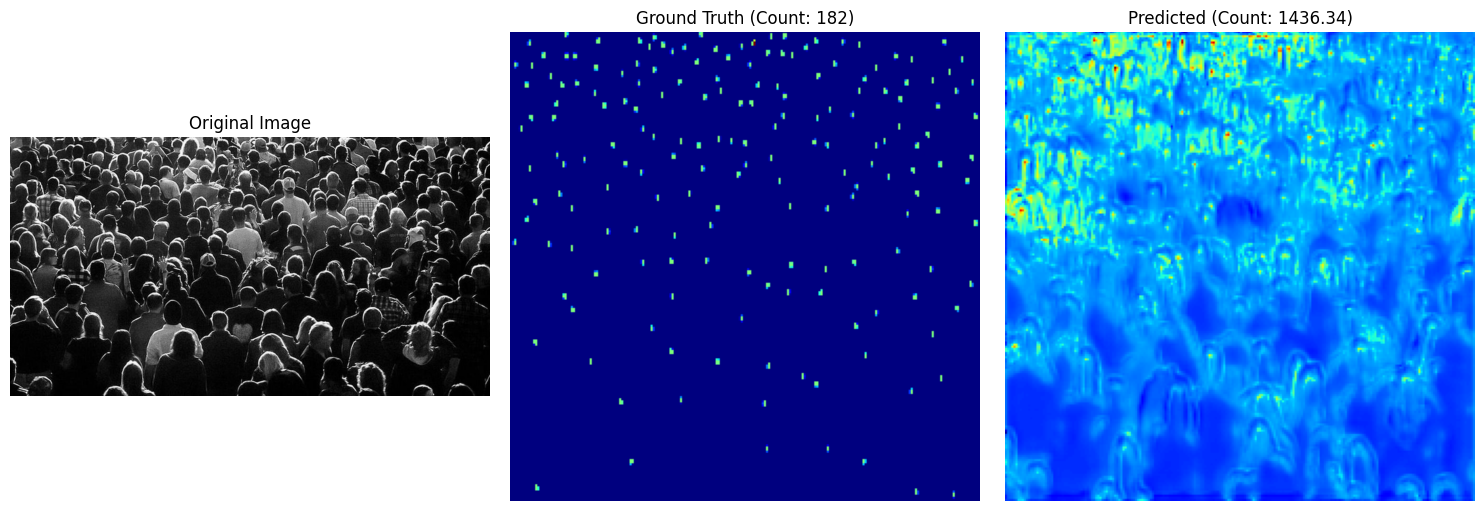

In [42]:
sample_index = 10
visualize_result(test_images[sample_index], test_gt[sample_index], model)
